In [1]:
# autoreload the imported packages
%load_ext autoreload
%autoreload 2

# Data
## Visualize the data

In [2]:
from scipy.io import loadmat

# Load the row data
data_mat = loadmat('data/dataset.mat')
unbalanced_data_mat = loadmat('data/unbalanced_dataset.mat')

# check the basic information about the data
print("data")
for k, v in data_mat.items():
    if not k.startswith('__'):
        print(k, type(v), v.shape)

# check the basic information about the unbalanced data
print("unbalanced_data")
for k, v in unbalanced_data_mat.items():
    if not k.startswith('__'):
        print(k, type(v), v.shape)

data
EEGsample <class 'numpy.ndarray'> (2022, 30, 384)
subindex <class 'numpy.ndarray'> (2022, 1)
substate <class 'numpy.ndarray'> (2022, 1)
unbalanced_data
EEGsample <class 'numpy.ndarray'> (2952, 30, 384)
subindex <class 'numpy.ndarray'> (2952, 1)
substate <class 'numpy.ndarray'> (2952, 1)


## Data preprocessing

In [3]:
import torch

# get the data, label and subject from the original data
data = data_mat['EEGsample']
label = data_mat['substate']
subject = data_mat['subindex']
unbalanced_data = unbalanced_data_mat['EEGsample']
unbalanced_label = unbalanced_data_mat['substate']
unbalanced_subject = unbalanced_data_mat['subindex']

# convert data from NumPy's ndarray to tensor
data = torch.from_numpy(data)
data = data.unsqueeze(1)
label = torch.from_numpy(label)
label = label.squeeze()
subject = torch.from_numpy(subject)
subject = subject.squeeze()
unbalanced_data = torch.from_numpy(unbalanced_data)
unbalanced_data = unbalanced_data.unsqueeze(1)
unbalanced_label = torch.from_numpy(unbalanced_label)
unbalanced_label = unbalanced_label.squeeze()
unbalanced_subject = torch.from_numpy(unbalanced_subject)
unbalanced_subject = unbalanced_subject.squeeze()
data = data.type(torch.float)
label = label.type(torch.long)
subject = subject.type(torch.long)
unbalanced_data = unbalanced_data.type(torch.float)
unbalanced_label = unbalanced_label.type(torch.long)
unbalanced_subject = unbalanced_subject.type(torch.long)

# get the shape of data, label and subject
print(f"data shape: {data.shape}, label shape: {label.shape}, subject shape: {subject.shape} | unbalanced data shape: {unbalanced_data.shape}, unbalanced label: {unbalanced_label.shape}, unbalanced subject: {unbalanced_subject.shape}")

data shape: torch.Size([2022, 1, 30, 384]), label shape: torch.Size([2022]), subject shape: torch.Size([2022]) | unbalanced data shape: torch.Size([2952, 1, 30, 384]), unbalanced label: torch.Size([2952]), unbalanced subject: torch.Size([2952])


## Create a dataset

In [4]:
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
import config


class DriveFatigueDataset(Dataset):
    def __init__(self, data: torch.Tensor, label: torch.Tensor, subject: torch.Tensor):
        super().__init__()
        self.data = data
        self.label = label
        self.subject = subject

    def __len__(self):
        return len(self.data)

    def __getitem__(self, item):
        return self.data[item], self.label[item], self.subject[item]

# Split the training and testing data
train_data, test_data, \
train_label, test_label, \
train_subject, test_subject = train_test_split(
    data,
    label,
    subject,
    test_size=config.test_data_rate,
    random_state=config.random_state,
    shuffle=True
)
train_unbalanced_data, test_unbalanced_data, \
train_unbalanced_label, test_unbalanced_label, \
train_unbalanced_subject, test_unbalanced_subject = train_test_split(
    unbalanced_data,
    unbalanced_label,
    unbalanced_subject,
    test_size=config.test_data_rate,
    random_state=config.random_state,
    shuffle=True
)

# Create instances of dataset
train_dataset = DriveFatigueDataset(train_data, train_label, train_subject)
test_dataset = DriveFatigueDataset(test_data, test_label, test_subject)
train_unbalanced_dataset = DriveFatigueDataset(train_unbalanced_data, train_unbalanced_label, train_unbalanced_subject)
test_unbalanced_dataset = DriveFatigueDataset(test_unbalanced_data, test_unbalanced_label, test_unbalanced_subject)

## Create a dataloader

In [5]:
from torch.utils.data import DataLoader
import config

# Set the torch random state
torch.manual_seed(config.random_state)

# Create instances of dataloader
train_dataloader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)
train_unbalanced_dataloader = DataLoader(train_unbalanced_dataset, batch_size=config.batch_size, shuffle=True)
test_unbalanced_dataloader = DataLoader(test_unbalanced_dataset, batch_size=config.batch_size, shuffle=False)

# Train and test model

model structure
EEGNetModel(
  (temporal): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (spatial): Conv2d(8, 16, kernel_size=(30, 1), stride=(1, 1), groups=8, bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (separable): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=16, out_features=2, bias=True)
  )
)


Testing: 100%|██████████| 10/10 [00:00<00:00, 199.18it/s]


Epoch: 0 | loss: 0.7021, acc: 50.10% | test loss: 0.6990 | test acc: 45.09%


Testing: 100%|██████████| 10/10 [00:00<00:00, 205.03it/s]


Epoch: 10 | loss: 0.6657, acc: 63.91% | test loss: 0.6823 | test acc: 50.13%


...

Testing: 100%|██████████| 10/10 [00:00<00:00, 236.29it/s]


Epoch: 80 | loss: 0.4793, acc: 79.62% | test loss: 0.7694 | test acc: 53.56%


Testing: 100%|██████████| 10/10 [00:00<00:00, 229.81it/s]


Epoch: 90 | loss: 0.4721, acc: 78.57% | test loss: 0.7759 | test acc: 54.04%


Testing: 100%|██████████| 10/10 [00:00<00:00, 238.10it/s]


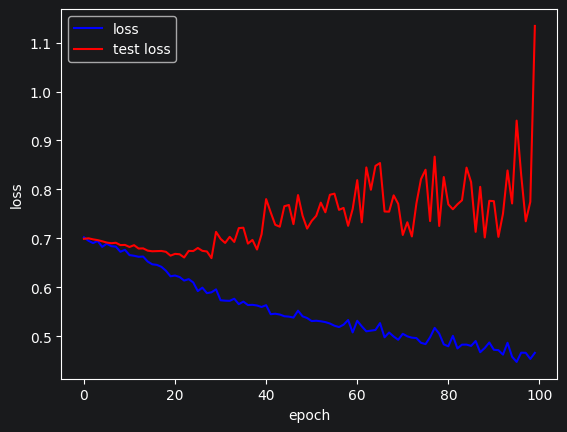

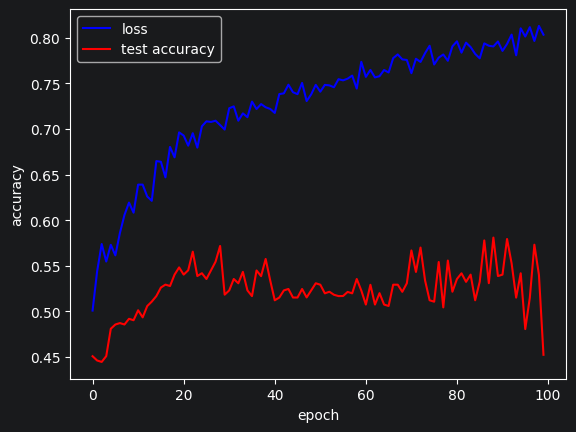

In [6]:
from models.EEGNetModel import EEGNetModel
import torch
import config
from tqdm import tqdm
from matplotlib import pyplot as plt
import torchmetrics

# Set up the device
device = config.device

# Create an instance of our model
model_0 = EEGNetModel()
print("model structure")
print(model_0)

# put the model to device
model_0.to(device)

# Set up the loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Set up the accuracy function
acc_fn = torchmetrics.Accuracy(task="binary")
acc_fn.to(device)

# Set up the optimizer
optimizer = torch.optim.Adam(lr=config.learning_rate, params=model_0.parameters())

# Set up the recording array
epoch_values = []
loss_values = []
test_loss_values = []
acc_values = []
test_acc_values = []

# training and testing loop
epochs = config.train_epoch
for epoch in range(epochs):
    epoch_values.append(epoch)

    # turn the model to training mode
    model_0.train()

    # loop through the batches
    total_loss, total_acc = 0, 0
    for x, y, sub in tqdm(train_dataloader, desc='Training'):

        # push the data to device
        x, y = x.to(device), y.to(device)

        # training process
        logits = model_0(x)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)
        loss = loss_fn(logits, y)
        acc = acc_fn(preds, y)
        total_loss += loss.item()
        total_acc += acc.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    avg_loss = total_loss / len(train_dataloader)
    avg_acc = total_acc / len(train_dataloader)
    loss_values.append(avg_loss)
    acc_values.append(avg_acc)

    # turn the model to evaluating mode
    model_0.eval()
    with torch.inference_mode():
        total_loss, total_acc = 0, 0
        for x_test, y_test, sub_test in tqdm(test_dataloader, desc='Testing'):

            # push the data to device
            x_test, y_test = x_test.to(device), y_test.to(device)

            # testing process
            logits_test = model_0(x_test)
            preds_test = torch.argmax(torch.softmax(logits_test, dim=1), dim=1)
            loss_test = loss_fn(logits_test, y_test)
            acc_test = acc_fn(preds_test, y_test)
            total_loss += loss_test.item()
            total_acc += acc_test.item()
        avg_test_loss = total_loss / len(test_dataloader)
        avg_test_acc = total_acc / len(test_dataloader)
        test_loss_values.append(avg_test_loss)
        test_acc_values.append(avg_test_acc)

    # show what's happen
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | loss: {avg_loss:.4f}, acc: {avg_acc*100:.2f}% | test loss: {avg_test_loss:.4f} | test acc: {avg_test_acc*100:.2f}%")

# plot the training and testing loss in each epoch
plt.figure()
plt.plot(epoch_values, loss_values, 'b-', label='loss')
plt.plot(epoch_values, test_loss_values, 'r-', label='test loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc='best')
plt.show()

# plot the training and testing accuracy in each epoch
plt.figure()
plt.plot(epoch_values, acc_values, 'b-', label='accuracy')
plt.plot(epoch_values, test_acc_values, 'r-', label='test accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(loc='best')
plt.show()
